## Setup

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

In [2]:
# Setup path and imports
import sys
import os

parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
os.chdir(parent_dir)

from utils import (
    load_all_historical, preprocess_historical_data, 
    check_data_quality, print_data_quality_report,
    train_val_test_split,
    plot_strategy_analysis, print_backtest_results, plot_comparison_charts,
    optimize_onestock, optimize_universal
)

# Import Linear Regression Strategies
from strategies import (
    LinearRegressionSlope, LinearRegressionChannel,
    ARIMAStrategy, GARCHVolatilityStrategy, ARIMAGARCHStrategy,
    backtest_strategy, compare_strategies
)

print("All modules imported successfully!")

All modules imported successfully!


In [3]:
USE_QLIB = False 

if USE_QLIB:
    try:
        from utils.data_loader import load_data_with_qlib
        symbols = ['VNM', 'VCB', 'VIC', 'VHM', 'HPG', 'MWG', 'VPB', 'MSN', 'ACB', 'BID']
        all_data = load_data_with_qlib(
            symbols=symbols,
            start_date='2020-01-01',
            end_date='2024-12-31',
            csv_dir='data/historical'
        )
    except:
        USE_QLIB = False

if not USE_QLIB:
    all_data = load_all_historical('data/historical', preprocess=True)

# Check data quality
for symbol, df in all_data.items():
    report = check_data_quality(df, symbol)
    print_data_quality_report(report)

print(f"\nLoaded historical data for {len(all_data)} symbols: {list(all_data.keys())}")

✓ Loaded historical data for 10 symbols

 Data Quality Report: ACB

📊 Overview:
   Total Rows:    4737
   Date Range:    2006-11-21 00:00:00 to 2025-12-03 00:00:00

✅ No missing values

✅ No duplicate dates



 Data Quality Report: BID

📊 Overview:
   Total Rows:    2956
   Date Range:    2014-01-24 00:00:00 to 2025-12-03 00:00:00

✅ No missing values

✅ No duplicate dates



 Data Quality Report: HPG

📊 Overview:
   Total Rows:    4500
   Date Range:    2007-11-15 00:00:00 to 2025-12-03 00:00:00

✅ No missing values

✅ No duplicate dates



 Data Quality Report: MSN

📊 Overview:
   Total Rows:    4011
   Date Range:    2009-11-05 00:00:00 to 2025-12-03 00:00:00

✅ No missing values

✅ No duplicate dates



 Data Quality Report: MWG

📊 Overview:
   Total Rows:    2846
   Date Range:    2014-07-14 00:00:00 to 2025-12-03 00:00:00

✅ No missing values

✅ No duplicate dates



 Data Quality Report: VCB

📊 Overview:
   Total Rows:    4101
   Date Range:    2009-06-30 00:00:00 to 2025-12-03 

In [4]:
# Select a sample symbol for demo
SYMBOL = 'VNM'
df = all_data[SYMBOL].copy()
print(f"\nSample data for {SYMBOL}: {len(df)} rows, from {df['date'].min()} to {df['date'].max()}")

# Train / Val / Test Split
train_df, val_df, test_df = train_val_test_split(df, train_ratio=0.6, val_ratio=0.2, test_ratio=0.2)
print(f"Train set: {len(train_df)} rows ({train_df['date'].min()} to {train_df['date'].max()})")
print(f"Validation set: {len(val_df)} rows ({val_df['date'].min()} to {val_df['date'].max()})")
print(f"Test set: {len(test_df)} rows ({test_df['date'].min()} to {test_df['date'].max()})")


Sample data for VNM: 4955 rows, from 2006-01-19 00:00:00 to 2025-12-03 00:00:00
Train set: 2973 rows (2006-01-19 00:00:00 to 2017-12-20 00:00:00)
Validation set: 991 rows (2017-12-21 00:00:00 to 2021-12-09 00:00:00)
Test set: 991 rows (2021-12-10 00:00:00 to 2025-12-03 00:00:00)


---
# Part 1: Linear Regression Strategies

Using sklearn's LinearRegression for:
1. **Slope Strategy** - Trade based on regression trend direction
2. **Channel Strategy** - Mean reversion within regression bands

## 1.1 Linear Regression Slope Strategy

In [5]:
# Strategy: Buy when slope is positive and R² is high (strong uptrend)
param_space = {
    'window': ('int', 5, 30),
    'r2_threshold': ('float', 0.5, 0.95),
}
best_params = optimize_onestock(
    strategy_class=LinearRegressionSlope,
    train_df=train_df,
    val_df=val_df,
    param_space=param_space,
    backtest_fn=backtest_strategy,
)

print(f"\nBest parameters for LinearRegressionSlope on {SYMBOL}: {best_params}")

  0%|          | 0/100 [00:00<?, ?it/s]


Best parameters for LinearRegressionSlope on VNM: {'best_params': {'window': 30, 'r2_threshold': 0.5023837043662964}, 'train_score': np.float64(0.7680609308202382), 'val_score': np.float64(0.04929243101291032), 'overfit_gap': np.float64(0.7187684998073278), 'train_trades': np.float64(43.5), 'val_trades': np.float64(10.0), 'study': <optuna.study.study.Study object at 0x0000022AC7123520>, 'all_results': [{'params': {'window': 14, 'r2_threshold': 0.9278214378844623}, 'train_score': np.float64(0.1194553803433253), 'val_score': np.float64(-0.5512549068520716), 'overfit_gap': np.float64(0.6707102871953968), 'adjusted_score': np.float64(-0.08175770581529375), 'train_trades': np.float64(16.0), 'val_trades': np.float64(1.0)}, {'params': {'window': 24, 'r2_threshold': 0.7693963178886665}, 'train_score': np.float64(0.26248419002202755), 'val_score': np.float64(-0.30304132222013497), 'overfit_gap': np.float64(0.5655255122421625), 'adjusted_score': np.float64(0.09282653634937879), 'train_trades': 


LinearRegressionSlope
Total Return:   -8.53%
Annual Return:  -2.24%
Sharpe Ratio:   -0.30
Max Drawdown:   -17.84%
Win Rate:       49.68%
Num Trades:     10


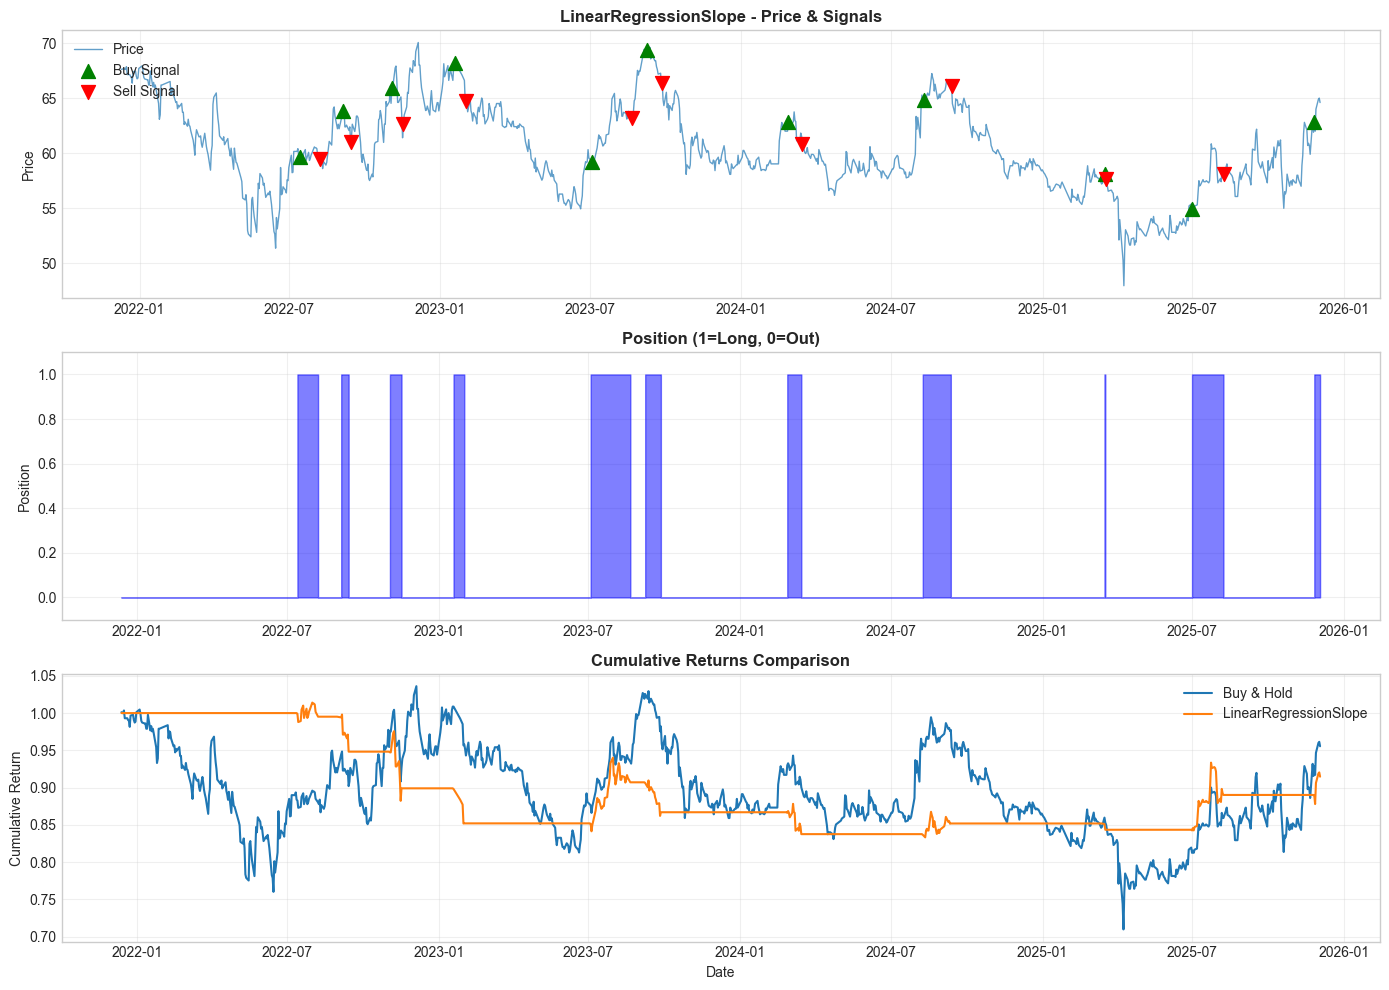

In [7]:
# Backtest with best parameters on the test set
strategy = LinearRegressionSlope(**best_params['best_params'])
result = strategy.generate_signals(test_df)
backtest = backtest_strategy(test_df, strategy)

print_backtest_results(backtest, 'LinearRegressionSlope')
plot_strategy_analysis(test_df, result, backtest, strategy_name='LinearRegressionSlope')

## 1.2 Linear Regression Channel Strategy

In [7]:
# Strategy: Mean reversion within regression channel bands
lr_channel = LinearRegressionChannel(window=50, num_std=2.0)
result_channel = lr_channel.generate_signals(df)
backtest_channel = backtest_regression_strategy(df, lr_channel)

print_backtest_results(backtest_channel, "Linear Regression Channel (50-day, ±2σ)")


Linear Regression Channel (50-day, ±2σ)
Total Return:   74.30%
Annual Return:  2.87%
Sharpe Ratio:   0.15
Max Drawdown:   -63.23%
Win Rate:       46.71%
Num Trades:     51


## 1.4 Compare All Regression Strategies

---
# Part 2: Time-Series Model Strategies

Using statsmodels (ARIMA) and arch (GARCH) for:
1. **ARIMA Strategy** - Price forecasting
2. **GARCH Volatility** - Volatility regime detection
3. **ARIMA-GARCH Combined** - Joint return & volatility forecasting